In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

dataset = pd.read_parquet("/Users/ryanaskin/Documents/datasci-challenge/renewables-dataset.parquet")

# Ensure the time column is parsed as datetime
dataset["Time"] = pd.to_datetime(dataset["Time"])

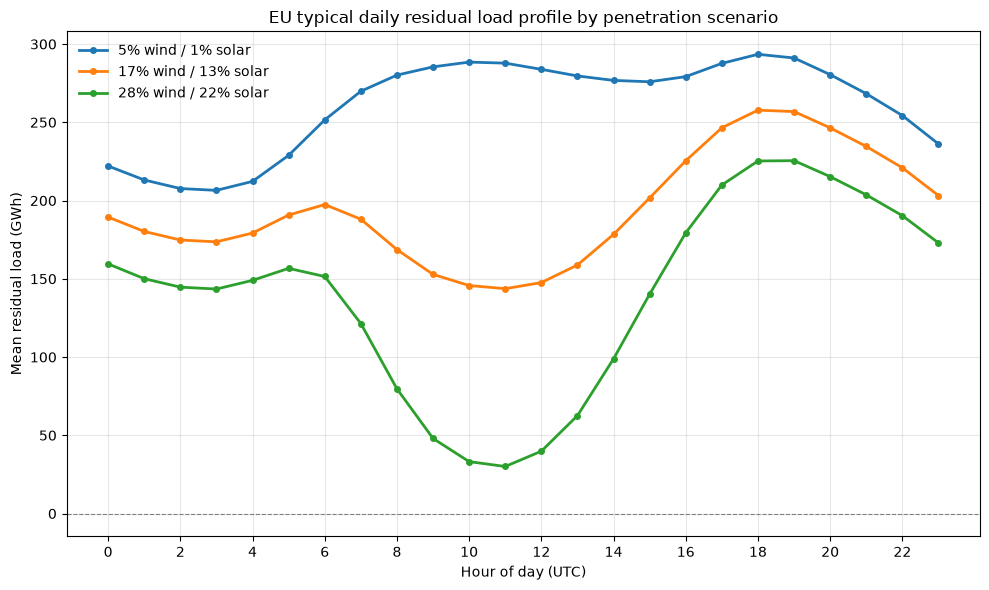

In [48]:
# Four scenarios: (label, a_wind, a_solar)
SCENARIOS = [
    ("5% wind / 1% solar",     0.050, 0.010),
    ("17% wind / 13% solar",  0.170, 0.13),
    ("28% wind / 22% solar",  0.28, 0.220),
]

def eu_diurnal(dataset, a_w, a_s):
    """EU-aggregated mean residual load by hour of day (UTC), in GWh."""
    residual = (dataset["demand_MWh"]
                - a_s * dataset["solar_MWh"]
                - a_w * dataset["wind_MWh"])
    df = pd.DataFrame({"Time": dataset["Time"], "residual_MWh": residual})
    eu = df.groupby("Time", as_index=False)["residual_MWh"].sum()
    eu["hour"] = pd.to_datetime(eu["Time"], utc=True).dt.hour
    return eu.groupby("hour")["residual_MWh"].mean() / 1000  # → GWh


# Compute one diurnal profile per scenario
profiles = {label: eu_diurnal(dataset, a_w, a_s)
            for label, a_w, a_s in SCENARIOS}

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for label, series in profiles.items():
    ax.plot(series.index, series.values, marker="o",
            linewidth=2, markersize=4, label=label)

ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Mean residual load (GWh)")
ax.set_title("EU typical daily residual load profile by penetration scenario")
ax.legend(loc="best", frameon=False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

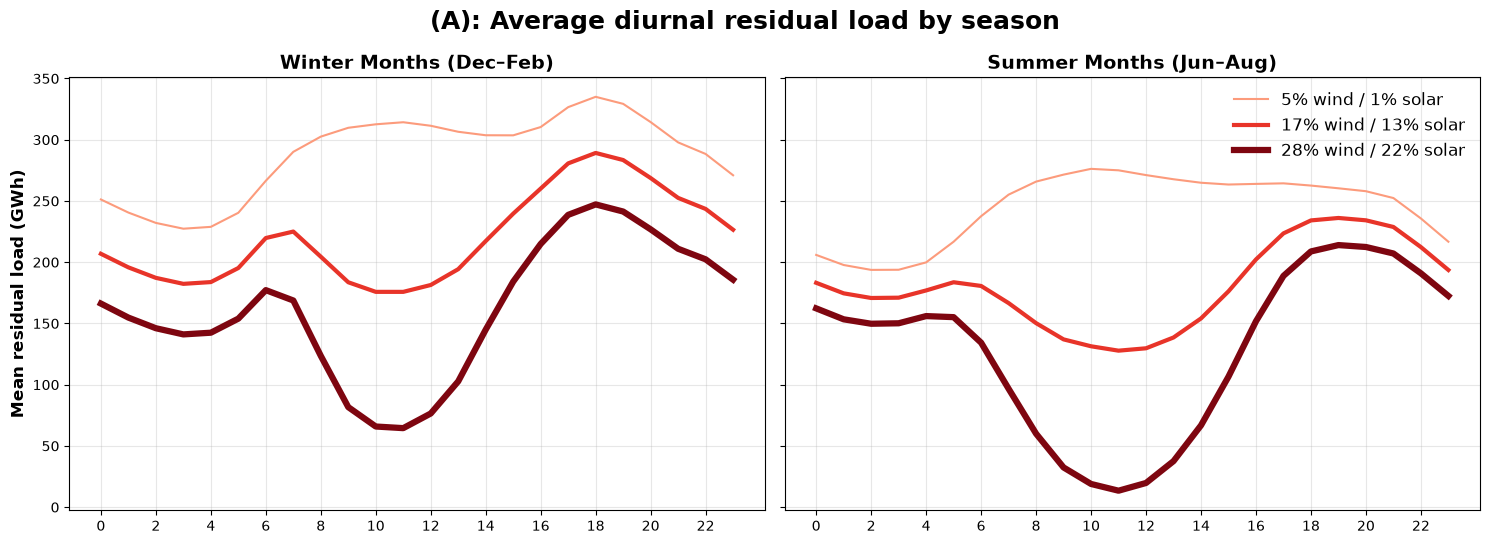

In [84]:
WINTER_MONTHS = [12, 1, 2]
SUMMER_MONTHS = [6, 7, 8]
import matplotlib.cm as cm

n = len(SCENARIOS)
# Sample from 0.35 to 0.95 to avoid the palest end (near-invisible) and pure black
colors = {label: cm.Reds(0.35 + 0.6 * i / (n - 1))
          for i, (label, _, _) in enumerate(SCENARIOS)}
widths = {label: 1.5 + 1.5 * i for i, (label, _, _) in enumerate(SCENARIOS)}

def eu_seasonal_diurnal(dataset, a_w, a_s, months):
    """EU-aggregated mean residual load by hour, filtered to given months. Returns GWh."""
    residual = (dataset["demand_MWh"]
                - a_s * dataset["solar_MWh"]
                - a_w * dataset["wind_MWh"])
    df = pd.DataFrame({"Time": dataset["Time"], "residual_MWh": residual})
    eu = df.groupby("Time", as_index=False)["residual_MWh"].sum()
    t = pd.to_datetime(eu["Time"], utc=True)
    eu["hour"]  = t.dt.hour
    eu["month"] = t.dt.month
    eu = eu[eu["month"].isin(months)]
    return eu.groupby("hour")["residual_MWh"].mean() / 1000  # → GWh


# Compute all profiles
winter = {label: eu_seasonal_diurnal(dataset, a_w, a_s, WINTER_MONTHS)
          for label, a_w, a_s in SCENARIOS}
summer = {label: eu_seasonal_diurnal(dataset, a_w, a_s, SUMMER_MONTHS)
          for label, a_w, a_s in SCENARIOS}

# Shared y-limits so the two panels are visually comparable
all_vals = np.concatenate([s.values for s in list(winter.values()) + list(summer.values())])
ymin, ymax = all_vals.min(), all_vals.max()
pad = 0.05 * (ymax - ymin)
ylim = (ymin - pad, ymax + pad)

# Plot
fig, (ax_w, ax_s) = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

for label, series in winter.items():
    ax_w.plot(series.index, series.values, color=colors[label],
              linewidth=widths[label], markersize=4, label=label)
for label, series in summer.items():
    ax_s.plot(series.index, series.values, color=colors[label],
              linewidth=widths[label], markersize=4, label=label)

for ax, title in [(ax_w, "Winter Months (Dec–Feb)"), (ax_s, "Summer Months (Jun–Aug)")]:
    #ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_xticks(range(0, 24, 2))
    #ax.set_xlabel("Hour of day (UTC)", fontsize = 12, fontweight = "bold")
    ax.set_title(title, fontsize=14, fontweight = "bold")
    ax.grid(alpha=0.3)
    ax.set_ylim(ylim)

fig.suptitle("(A): Average diurnal residual load by season", fontsize=18, fontweight = 'bold')
ax_w.set_ylabel("Mean residual load (GWh)", fontsize = 12, fontweight = "bold")
ax_s.legend(loc="best", frameon=False, fontsize = 12)


plt.tight_layout()
plt.savefig("total_residual_load.pdf", bbox_inches="tight", transparent=False)
plt.show()

In [85]:
def country_diurnal(dataset, country, a_w, a_s):
    """Mean diurnal residual load as a fraction of country's annual mean demand."""
    d = dataset[dataset["country"] == country]
    hourly = d.groupby("Time", as_index=False).agg(
        demand=("demand_MWh", "sum"),
        solar=("solar_MWh",  "sum"),
        wind=("wind_MWh",    "sum"),
    )
    hourly["residual"] = (hourly["demand"]
                          - a_s * hourly["solar"]
                          - a_w * hourly["wind"])
    annual_mean_demand = hourly["demand"].mean()
    t = pd.to_datetime(hourly["Time"], utc=True)
    hourly["hour"] = t.dt.hour
    return hourly.groupby("hour")["residual"].mean() / annual_mean_demand

In [86]:
# --- Compare France (nuclear-heavy) vs Portugal (renewable-exposed) ---
selected = ["FRA", "POR"]

profiles = {(c, label): country_diurnal(dataset, c, aw, as_)
            for c in selected
            for label, aw, as_ in SCENARIOS}

# Shared y-limits across both panels
all_vals = np.concatenate([s.values for s in profiles.values()])
pad = 0.05 * (all_vals.max() - all_vals.min())
ylim = (all_vals.min() - pad, all_vals.max() + pad)

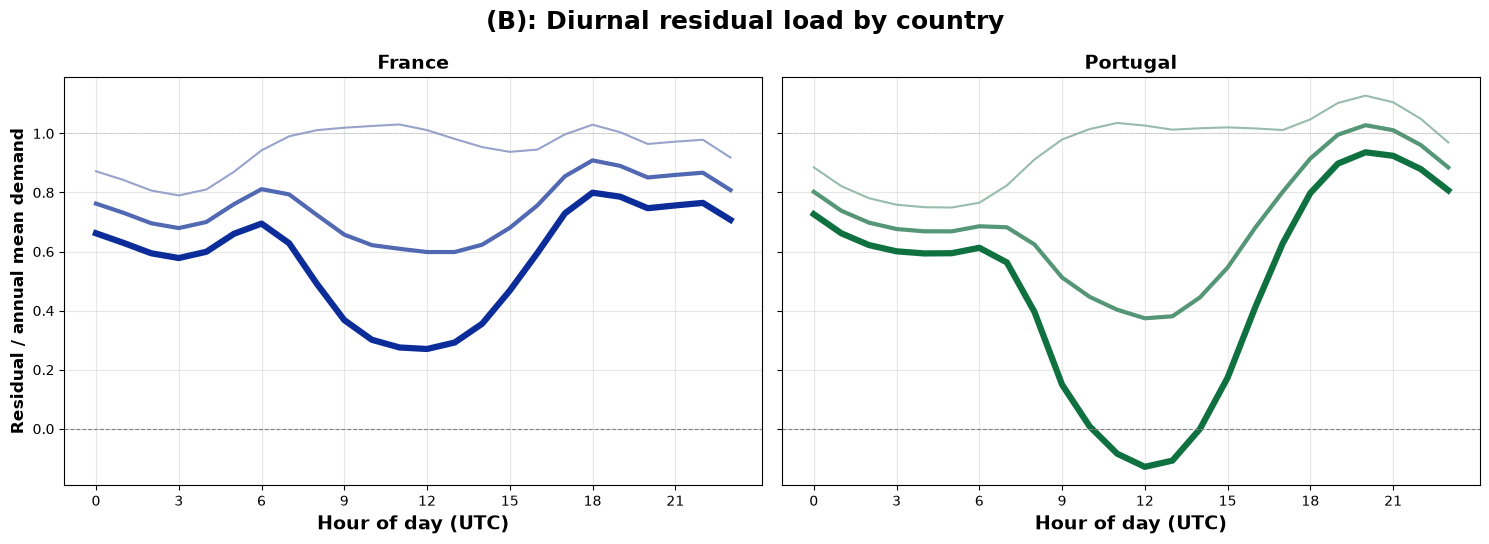

In [89]:
import matplotlib.colors as mcolors

# Dominant flag colour per country (France: blue; Portugal: green)
country_base = {
    "FRA": "#002395",   # French flag blue
    "POR": "#046A38",   # Portuguese flag green
}

# Build a light→dark colormap per country
country_cmaps = {
    c: mcolors.LinearSegmentedColormap.from_list(c, ["#e8e8e8", base])
    for c, base in country_base.items()
}

n = len(SCENARIOS)
def scenario_color(country, i):
    return country_cmaps[country](0.35 + 0.6 * i / (n - 1))

widths = {label: 1.5 + 1.5 * i for i, (label, _, _) in enumerate(SCENARIOS)}

# 1x2 grid: one panel per country, scenarios overlaid 
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharex=True, sharey=True)

for ax, country in zip(axes, selected):
    for i, (label, _, _) in enumerate(SCENARIOS):
        s = profiles[(country, label)]
        ax.plot(s.index, s.values,
                linewidth=widths[label],
                color=scenario_color(country, i), label=label)
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.axhline(1, color="grey", linewidth=0.6, linestyle=":", alpha=0.6)
    ax.grid(alpha=0.3)
    ax.set_xticks(range(0, 24, 3))
    ax.set_ylim(ylim)
    ax.set_xlabel("Hour of day (UTC)", fontsize = 14, fontweight = 'bold')
    panel_labels = {"FRA": "France", "POR": "Portugal"}
    ax.set_title(panel_labels[country], fontsize=14, fontweight = 'bold')

fig.suptitle("(B): Diurnal residual load by country", fontsize=18, fontweight = 'bold')
axes[0].set_ylabel("Residual / annual mean demand", fontsize=12, fontweight = 'bold')
#axes[1].legend(loc="best", frameon=False, fontsize=12)


plt.tight_layout()
plt.savefig("country_comparison_residual_load.pdf", bbox_inches="tight", transparent=False)
plt.show()